<a href="https://colab.research.google.com/github/Erwin2Sibaja/challenge_3-Telecom-X-anlisis-de-evasion-de-clientes-Parte-2/blob/main/Telecom_X_%E2%80%93_Parte_2_Predicci%C3%B3n_de_Cancelaci%C3%B3n_(Churn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Extracción de datos

In [3]:
import pandas as pd

In [2]:
clientes = pd.read_json('/content/drive/MyDrive/Colab Notebooks/Challenge 2/TelecomX_Data.json')
clientes

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


## Diccionario e datos

*   **customerID**: número de identificación único de cada cliente
*   **Churn**: si el cliente dejó o no la empresa
*   **gender**: género (masculino y femenino)
*   **SeniorCitizen**: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
*   **Partner**: si el cliente tiene o no una pareja
*   **Dependents**: si el cliente tiene o no dependientes
*   **tenure**: meses de contrato del cliente
*   **PhoneService**: suscripción al servicio telefónico
*   **MultipleLines**: suscripción a más de una línea telefónica
*   **InternetService**: suscripción a un proveedor de internet
*   **OnlineSecurity**: suscripción adicional de seguridad en línea
*   **OnlineBackup**: suscripción adicional de respaldo en línea
*   **DeviceProtection**: suscripción adicional de protección del dispositivo
*   **TechSupport**: suscripción adicional de soporte técnico, menor tiempo de espera

*   **StreamingTV**: suscripción de televisión por cable
*   **StreamingMovies**: suscripción de streaming de películas
*   **Contract**: tipo de contrato
*   **PaperlessBilling**: si el cliente prefiere recibir la factura en línea
*   **PaymentMethod**: forma de pago
*   **Charges.Monthly**: total de todos los servicios del cliente por mes
*   **Charges.Total**: total gastado por el cliente

#Transformación

In [4]:
columnas_dict = ['customer', 'phone', 'internet', 'account']

for col in columnas_dict:
    clientes[col] = clientes[col].apply(lambda x: x if isinstance(x, dict) else {})

In [5]:
df_customer = pd.json_normalize(clientes['customer'])
df_phone = pd.json_normalize(clientes['phone'])
df_internet = pd.json_normalize(clientes['internet'])

df_account = pd.json_normalize(clientes['account'])

clientes_final = pd.concat([
    clientes.drop(columns=columnas_dict),
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)


clientes_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [10]:
clientes_final.shape

(7267, 21)

In [11]:
clientes_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [6]:
import numpy as np
from sklearn.preprocessing import StandardScaler

In [8]:
model = clientes_final.copy()

model['Churn'] = model['Churn'].replace('', pd.NA)
model = model.dropna(subset=['Churn'])

cols_limpiar = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in cols_limpiar:
    if col in model.columns:
        model[col] = model[col].replace({'No phone service': 'No', 'No internet service': 'No'})

for col in ['Charges.Monthly', 'Charges.Total']:
    if col in model.columns:
        model[col] = model[col].astype(str).str.replace(',', '.')
        model[col] = pd.to_numeric(model[col], errors='coerce')

model['Charges.Total'] = model['Charges.Total'].fillna(0)

cols_binarias = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in cols_binarias:
    if col in model.columns:
        model[col] = model[col].map({'Yes': 1, 'No': 0})

if 'gender' in model.columns:
    model['gender'] = model['gender'].map({'Female': 1, 'Male': 0})

model = pd.get_dummies(model.drop(columns=['customerID'], errors='ignore'),
                       columns=['Contract', 'PaymentMethod', 'InternetService'],
                       drop_first=True)

scaler = StandardScaler()
cols_num = ['tenure', 'Charges.Monthly', 'Charges.Total']
model[cols_num] = scaler.fit_transform(model[cols_num])

print("✅ Preprocesamiento completado. Dimensiones listas para ML:", model.shape)

✅ Preprocesamiento completado. Dimensiones listas para ML: (7043, 24)


In [12]:
model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7043 non-null   int64  
 1   gender                                 7043 non-null   int64  
 2   SeniorCitizen                          7043 non-null   int64  
 3   Partner                                7043 non-null   int64  
 4   Dependents                             7043 non-null   int64  
 5   tenure                                 7043 non-null   float64
 6   PhoneService                           7043 non-null   int64  
 7   MultipleLines                          7043 non-null   int64  
 8   OnlineSecurity                         7043 non-null   int64  
 9   OnlineBackup                           7043 non-null   int64  
 10  DeviceProtection                       7043 non-null   int64  
 11  TechSuppo

/tmp/ipykernel_1926/2461037597.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values, y=correlaciones.index, palette='coolwarm')


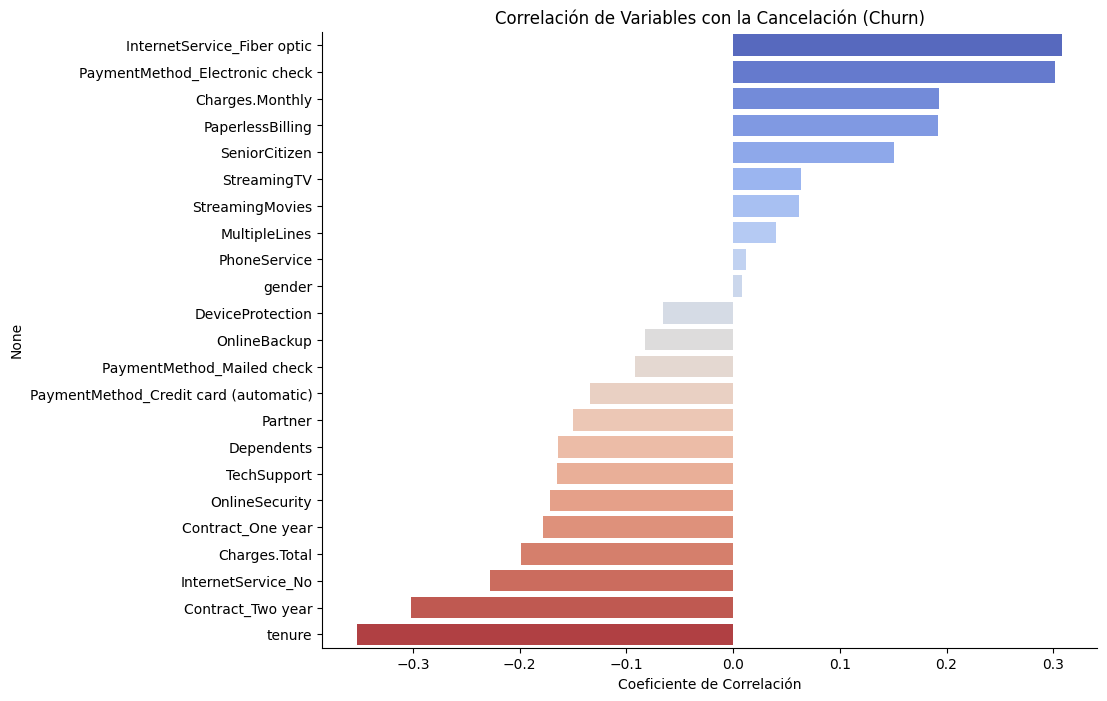


=== RENDIMIENTO: REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.843

=== RENDIMIENTO: RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.64      0.45      0.53       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.79      0.77      1409

ROC-AUC: 0.827


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

plt.figure(figsize=(10, 8))
correlaciones = model.corr()['Churn'].sort_values(ascending=False).drop('Churn')
sns.barplot(x=correlaciones.values, y=correlaciones.index, palette='coolwarm')
plt.title('Correlación de Variables con la Cancelación (Churn)')
plt.xlabel('Coeficiente de Correlación')
sns.despine()
plt.show()

X = model.drop('Churn', axis=1)
y = model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

modelo_log = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

modelo_log.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)

pred_log = modelo_log.predict(X_test)
pred_rf = modelo_rf.predict(X_test)

print("\n=== RENDIMIENTO: REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, pred_log))
print(f"ROC-AUC: {roc_auc_score(y_test, modelo_log.predict_proba(X_test)[:, 1]):.3f}")

print("\n=== RENDIMIENTO: RANDOM FOREST ===")
print(classification_report(y_test, pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, modelo_rf.predict_proba(X_test)[:, 1]):.3f}")